<a href="https://colab.research.google.com/github/lcandau/histopathology-clip-lab/blob/exp_07/experiments/exp_07_ood_eval/CLIP_OOD_eval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# exp_07 — OOD evaluation on NCT-CRC-HE-7K

Loads one of two LC25000-trained CLIP checkpoints and evaluates it on the NCT-CRC-HE-7K external colorectal pathology set restricted to the two mapped classes:

- `NORM` (NCT) ↔ `benign colon tissue` (LC25000 class 3)
- `TUM` (NCT) ↔ `colon adenocarcinoma` (LC25000 class 4)

**Variant** (set in Cell 2):
- `baseline` — raw-input baseline; NCT fed in raw.
- `stain_macenko_nct_ref` — LC25000 Macenko-normalised against an NCT NORM reference at training time; NCT fed in raw (single Macenko pass, no double-normalisation).

See `README.md` for design notes.


## 0 — Bootstrap

Self-contained Colab setup: clones the repo at the `exp_07` branch (so the dedupe + new loader resolve), installs pinned TF/Keras stack, mounts Drive for the cached baseline checkpoint.


In [1]:
# --- Cell 0: bootstrap ---
import os, sys, subprocess
os.environ["KERAS_BACKEND"] = "tensorflow"  # set before any keras import

REPO_URL = "https://github.com/lcandau/histopathology-clip-lab.git"
REPO_DIR = "/content/histopathology-clip-lab"
BRANCH = "exp_07"
IN_COLAB = "google.colab" in sys.modules


def _clone_with_fallback(branch):
    try:
        subprocess.run(
            ["git", "clone", "-b", branch, REPO_URL, REPO_DIR],
            check=True, capture_output=True,
        )
        print(f"Cloned branch {branch!r}")
        return branch
    except subprocess.CalledProcessError:
        print(f"Branch {branch!r} not found; cloning main")
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
        return "main"


if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        active = _clone_with_fallback(BRANCH)
    else:
        fetch = subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], capture_output=True)
        if fetch.returncode == 0:
            subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", f"origin/{BRANCH}"], check=True)
            active = BRANCH
        else:
            subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "checkout", "main"], check=True)
            subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)
            active = "main"
    print(f"Active branch: {active}")
    subprocess.run([
        "pip", "install", "-q",
        "tensorflow==2.18.0", "keras==3.7.0", "keras-hub==0.18.1",
        "umap-learn", "kagglehub",
        "scikit-learn", "matplotlib", "pandas", "Pillow",
    ], check=True)
    subprocess.run(["pip", "uninstall", "-y", "-q", "jax", "jaxlib"], check=False)

    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)

    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
else:
    LOCAL_REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    if LOCAL_REPO_DIR not in sys.path:
        sys.path.insert(0, LOCAL_REPO_DIR)

print("In Colab:", IN_COLAB)
print("sys.path[0]:", sys.path[0])
print("KERAS_BACKEND:", os.environ.get("KERAS_BACKEND"))


Cloned branch 'exp_07'
Active branch: exp_07
Mounted at /content/drive
In Colab: True
sys.path[0]: /content/histopathology-clip-lab
KERAS_BACKEND: tensorflow


## 1 — Imports


In [2]:
# --- Cell 1: imports ---
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import json
import math
import zipfile
import shutil
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
import keras
import keras_hub

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score,
)

# Repository helpers (loaded from the cloned repo).
from src.utils.paths import is_colab, repo_root, drive_root, run_dir, results_dir
from src.utils.repro import set_global_seed, enable_op_determinism
from src.data.lc25000 import CLASS_INFO, CLASS_NAMES, INDEX_TO_NAME, ID_TO_INDEX
from src.data.images import load_image
from src.prompts.templates import baseline_prompt


## 2 — Configuration

Hyperparameters mirror the LC25000 baseline at evaluation time. The only knobs are the NCT class mapping and the checkpoint path.


In [3]:
# --- Cell 2: config ---
EXPERIMENT = "exp_07_ood_eval"
SEED = 42
set_global_seed(SEED)
enable_op_determinism()

IMG_SIZE = 224
MAX_LEN = 24      # matches the training notebook
EMBED_DIM = 256
INIT_TEMP = 0.07
BATCH_SIZE = 64   # inference only; larger batch fine

# Which checkpoint to evaluate. Both are LC25000-trained 5-way CLIP models.
#   "baseline":              raw RGB inputs, no stain normalisation
#   "stain_macenko_nct_ref": LC25000 Macenko-normalised against an NCT NORM reference at train time
#                            -> NCT fed RAW at inference (single Macenko pass total, no double-norm).
VARIANT = "stain_macenko_nct_ref"   # one of: "baseline", "stain_macenko_nct_ref"

_CHECKPOINT_MAP = {
    "baseline":              run_dir("exp_01_baseline", "baseline") / "weights.weights.h5",
    "stain_macenko_nct_ref": run_dir("exp_04_stain_normalization", "stain_macenko_nct_ref") / "weights.weights.h5",
}
assert VARIANT in _CHECKPOINT_MAP, f"Unknown VARIANT {VARIANT!r}; pick one of {list(_CHECKPOINT_MAP)}"
CHECKPOINT_PATH = _CHECKPOINT_MAP[VARIANT]

# NCT-CRC-HE-7K source (Zenodo; mirrored Kather 2019).
NCT_URL  = "https://zenodo.org/records/1214456/files/CRC-VAL-HE-7K.zip"
NCT_NAME = "CRC-VAL-HE-7K"

# NCT folder name -> LC25000 prompt class name.
NCT_TO_LC25000 = {
    "NORM": "benign colon tissue",
    "TUM":  "colon adenocarcinoma",
}

# Drive caches.
DRIVE_OOD_ZIP   = drive_root() / "ood_datasets" / f"{NCT_NAME}.zip"
LOCAL_OOD_ROOT  = Path("/content/ood_data") if is_colab() else Path("/tmp/ood_data")
LOCAL_OOD_DIR   = LOCAL_OOD_ROOT / NCT_NAME

# Output directories.
METRICS_DIR = results_dir("metrics") / EXPERIMENT
CM_DIR      = results_dir("confusion_matrices") / EXPERIMENT
PLOTS_DIR   = results_dir("plots") / EXPERIMENT
for d in (METRICS_DIR, CM_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Variant:    {VARIANT}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Local OOD dir: {LOCAL_OOD_DIR}")
print(f"Metrics out:   {METRICS_DIR}")


Variant:    stain_macenko_nct_ref
Checkpoint: /content/drive/MyDrive/clip_histopathology/exp_04_stain_normalization/stain_macenko_nct_ref/weights.weights.h5
Local OOD dir: /content/ood_data/CRC-VAL-HE-7K
Metrics out:   /content/histopathology-clip-lab/results/metrics/exp_07_ood_eval


## 3 — Acquire NCT-CRC-HE-7K

Tries the Drive cache first (~1.6 GB) and falls back to a Zenodo download. After extract the disk layout is `<NCT root>/<class_id>/<file>.tif`.


In [4]:
# --- Cell 3: download / extract NCT-CRC ---
def _ensure_nct_zip(path):
    """Copy from Drive cache if present; otherwise download from Zenodo and persist to Drive."""
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        print(f"NCT zip already at {path}")
        return path
    DRIVE_OOD_ZIP.parent.mkdir(parents=True, exist_ok=True)
    if DRIVE_OOD_ZIP.exists():
        print(f"Copying NCT zip from Drive cache {DRIVE_OOD_ZIP} -> {path}")
        shutil.copy(DRIVE_OOD_ZIP, path)
        return path
    print(f"Downloading NCT-CRC from {NCT_URL} ...")
    urllib.request.urlretrieve(NCT_URL, path)
    print(f"Copying download to Drive cache: {DRIVE_OOD_ZIP}")
    shutil.copy(path, DRIVE_OOD_ZIP)
    return path


nct_zip_local = LOCAL_OOD_ROOT / f"{NCT_NAME}.zip"
_ensure_nct_zip(nct_zip_local)

if not LOCAL_OOD_DIR.exists() or not any(LOCAL_OOD_DIR.iterdir()):
    print(f"Extracting {nct_zip_local} -> {LOCAL_OOD_ROOT}")
    with zipfile.ZipFile(nct_zip_local) as zf:
        zf.extractall(LOCAL_OOD_ROOT)

# After extraction the dir layout is LOCAL_OOD_ROOT/CRC-VAL-HE-7K/<class>/<file>.tif
class_dirs = sorted(p for p in LOCAL_OOD_DIR.iterdir() if p.is_dir())
print("\nClasses on disk:")
for cd in class_dirs:
    n = len(list(cd.iterdir()))
    print(f"  {cd.name:>5s}  ({n} tiles)")


Copying NCT zip from Drive cache /content/drive/MyDrive/clip_histopathology/ood_datasets/CRC-VAL-HE-7K.zip -> /content/ood_data/CRC-VAL-HE-7K.zip
Extracting /content/ood_data/CRC-VAL-HE-7K.zip -> /content/ood_data

Classes on disk:
    ADI  (1338 tiles)
   BACK  (847 tiles)
    DEB  (339 tiles)
    LYM  (634 tiles)
    MUC  (1035 tiles)
    MUS  (592 tiles)
   NORM  (741 tiles)
    STR  (421 tiles)
    TUM  (1233 tiles)


## 4 — Discover OOD records

We keep only the two NCT classes that map cleanly to LC25000 colon classes. The other 7 (ADI/BACK/DEB/LYM/MUC/MUS/STR) are skipped.


In [5]:
# --- Cell 4: discover OOD records (NORM + TUM only) ---
ood_paths = []
ood_nct_labels = []  # NCT-class string for each path
for nct_cls in NCT_TO_LC25000:
    class_dir = LOCAL_OOD_DIR / nct_cls
    files = sorted(class_dir.iterdir())
    for f in files:
        if f.suffix.lower() in {".tif", ".tiff", ".png", ".jpg", ".jpeg"}:
            ood_paths.append(str(f))
            ood_nct_labels.append(nct_cls)

ood_paths = np.asarray(ood_paths)
ood_nct_labels = np.asarray(ood_nct_labels)
print(f"Total OOD tiles (NORM + TUM): {len(ood_paths)}")
for nct_cls in NCT_TO_LC25000:
    n = int((ood_nct_labels == nct_cls).sum())
    print(f"  {nct_cls}: {n}")

# Map NCT label -> LC25000 class index (using the prompt-name mapping).
ood_lc_indices = np.array([ID_TO_INDEX[next(c.id for c in CLASS_INFO if c.name == NCT_TO_LC25000[lab])]
                           for lab in ood_nct_labels], dtype=np.int32)
print(f"\nLC25000 colon class indices in use: {sorted(set(ood_lc_indices.tolist()))}")


Total OOD tiles (NORM + TUM): 1974
  NORM: 741
  TUM: 1233

LC25000 colon class indices in use: [3, 4]


## 5 — Build CLIP model

Same architecture as the LC25000 baseline: frozen `resnet_50_imagenet` image backbone + frozen `bert_base_en_uncased` text backbone, with `Dense(256, no bias) → LayerNorm` projection heads on both sides and a learnable temperature scalar.

The model is built once and the projection-head weights are loaded from the Drive checkpoint.


In [6]:
# --- Cell 5: CLIPModel definition (matches the training notebook) ---
class CLIPModel(keras.Model):
    def __init__(self, img_backbone, text_backbone, embed_dim=EMBED_DIM, init_temp=INIT_TEMP, **kwargs):
        super().__init__(**kwargs)
        self.img_backbone = img_backbone
        self.text_backbone = text_backbone

        self.img_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="img_projection")
        self.text_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="text_projection")

        self.logit_scale = self.add_weight(
            name="logit_scale", shape=(),
            initializer=keras.initializers.Constant(math.log(1.0 / init_temp)),
            trainable=True, dtype="float32",
        )
        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def encode_image(self, images, training=False):
        features = self.img_backbone(images, training=False)
        if features.shape.rank == 4:
            features = tf.reduce_mean(features, axis=[1, 2])
        x = self.img_projection(features)
        return tf.math.l2_normalize(x, axis=-1)

    def encode_text(self, token_dict, training=False):
        out = self.text_backbone(token_dict, training=False)
        if isinstance(out, dict):
            features = out.get("pooled_output", out.get("sequence_output"))
            if features is not None and features.shape.rank == 3:
                features = features[:, 0, :]
        else:
            features = out[:, 0, :] if out.shape.rank == 3 else out
        x = self.text_projection(features)
        return tf.math.l2_normalize(x, axis=-1)

    def call(self, inputs, training=False):
        images, token_dict = inputs
        return self.encode_image(images, training=training), self.encode_text(token_dict, training=training)


# Backbones.
image_backbone = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")
text_backbone  = keras_hub.models.Backbone.from_preset("bert_base_en_uncased")
image_backbone.trainable = False
text_backbone.trainable  = False

text_pre = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    "bert_base_en_uncased", sequence_length=MAX_LEN,
)

model = CLIPModel(image_backbone, text_backbone)

# Warm-up forward pass so all weights are materialised before load_weights.
class_prompts = [baseline_prompt(name) for name in CLASS_NAMES]
class_token_dict = text_pre(tf.constant(class_prompts))
dummy_imgs = tf.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32)
dummy_toks = {k: tf.constant(v[:1]) for k, v in class_token_dict.items()}
_ = model((dummy_imgs, dummy_toks), training=False)

n_trainable = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
n_total     = sum(int(np.prod(v.shape)) for v in model.variables)
print(f"Trainable params: {n_trainable:,}  (expected ~720K)")
print(f"Total params:     {n_total:,}")


Trainable params: 721,921  (expected ~720K)
Total params:     133,765,387


## 6 — Load baseline checkpoint


In [7]:
# --- Cell 6: load weights ---
assert CHECKPOINT_PATH.is_file(), (
    f"Missing checkpoint at {CHECKPOINT_PATH}.\n"
    f"Make sure the training notebook for variant {VARIANT!r} has been run and the\n"
    f"weights file is in Drive at the expected path."
)
model.load_weights(str(CHECKPOINT_PATH))
print(f"Loaded weights from {CHECKPOINT_PATH}")


Loaded weights from /content/drive/MyDrive/clip_histopathology/exp_04_stain_normalization/stain_macenko_nct_ref/weights.weights.h5


## 7 — Encode the 5 LC25000 class-prompt embeddings

We still encode all five prompts (the model is a 5-way classifier). At classification time we restrict argmax to the two colon classes that have NCT correspondents.


In [8]:
# --- Cell 7: class prompt embeddings ---
prompt_embeddings_all = model.encode_text(class_token_dict, training=False).numpy()  # (5, EMBED_DIM)
print(f"5 class-prompt embeddings: shape {prompt_embeddings_all.shape}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  [{i}] {name}: norm={float(np.linalg.norm(prompt_embeddings_all[i])):.4f}")


5 class-prompt embeddings: shape (5, 256)
  [0] benign lung tissue: norm=1.0000
  [1] lung adenocarcinoma: norm=1.0000
  [2] lung squamous cell carcinoma: norm=1.0000
  [3] benign colon tissue: norm=1.0000
  [4] colon adenocarcinoma: norm=1.0000


## 8 — Encode OOD test images and classify

We encode every NORM/TUM tile, compute cosine similarity against all 5 class prompts, restrict argmax to the two colon classes (indices 3 and 4 in LC25000), and report metrics.


In [9]:
# --- Cell 8: encode OOD + classify ---
# NCT-CRC ships .tif files, which tf.io.decode_image cannot decode (only handles
# JPEG/PNG/GIF/BMP). PIL decodes TIFF natively, so we bypass tf.data for OOD eval.
# ~2K colon tiles -> a Python loop is fast enough.

def encode_paths(paths, batch_size=BATCH_SIZE):
    out = []
    n = len(paths)
    for start in range(0, n, batch_size):
        batch_paths = paths[start:start + batch_size]
        batch_arrs = []
        for p in batch_paths:
            img = Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
            batch_arrs.append(np.asarray(img, dtype=np.float32) / 255.0)
        batch_tensor = tf.constant(np.stack(batch_arrs))
        emb = model.encode_image(batch_tensor, training=False).numpy()
        out.append(emb)
    return np.concatenate(out, axis=0)


print(f"Encoding {len(ood_paths)} OOD tiles...")
ood_embeddings = encode_paths(ood_paths)
print(f"OOD embeddings shape: {ood_embeddings.shape}")

# Cosine similarity to all 5 class prompts.
sims_all = ood_embeddings @ prompt_embeddings_all.T  # (N, 5)

# Restrict to the colon class subset for classification.
COLON_IDX = sorted({ID_TO_INDEX[next(c.id for c in CLASS_INFO if c.name == NCT_TO_LC25000[lab])]
                    for lab in NCT_TO_LC25000})
print(f"Restricting argmax to colon classes: {COLON_IDX}")
sims_colon = sims_all[:, COLON_IDX]
pred_within_colon = sims_colon.argmax(axis=1)
y_pred = np.array([COLON_IDX[i] for i in pred_within_colon], dtype=np.int32)
y_true = ood_lc_indices

print(f"y_pred unique: {sorted(set(y_pred.tolist()))}")
print(f"y_true unique: {sorted(set(y_true.tolist()))}")


Encoding 1974 OOD tiles...
OOD embeddings shape: (1974, 256)
Restricting argmax to colon classes: [3, 4]
y_pred unique: [3, 4]
y_true unique: [3, 4]


## 9 — Metrics + confusion matrix


In [10]:
# --- Cell 9: metrics ---
labels = COLON_IDX
target_names = [INDEX_TO_NAME[i] for i in labels]

acc      = accuracy_score(y_true, y_pred)
bal      = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
wgt_f1   = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

print(f"OOD ({VARIANT} -> NCT-CRC-HE-7K, NORM + TUM)\n")
print(f"  accuracy          = {acc:.4f}")
print(f"  balanced accuracy = {bal:.4f}")
print(f"  macro F1          = {macro_f1:.4f}")
print(f"  weighted F1       = {wgt_f1:.4f}")

per_class = classification_report(
    y_true, y_pred, labels=labels, target_names=target_names,
    output_dict=True, zero_division=0,
)
per_class_df = pd.DataFrame(per_class).T
print("\nPer-class:")
print(per_class_df.round(4).to_string())

# Confusion matrix (raw + row-normalised).
cm_raw = confusion_matrix(y_true, y_pred, labels=labels)
row_sums = cm_raw.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_raw, row_sums, where=row_sums > 0,
                    out=np.zeros_like(cm_raw, dtype=np.float64))

metrics_payload = {
    "experiment":          EXPERIMENT,
    "variant":             VARIANT,
    "checkpoint":          str(CHECKPOINT_PATH),
    "ood_dataset":         NCT_NAME,
    "n_tiles":             int(len(ood_paths)),
    "accuracy":            float(acc),
    "balanced_accuracy":   float(bal),
    "macro_f1":            float(macro_f1),
    "weighted_f1":         float(wgt_f1),
    "per_class":           per_class,
    "colon_indices":       labels,
    "target_names":        target_names,
}
metrics_path = METRICS_DIR / f"{VARIANT}_ood_classification.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2))
np.save(CM_DIR / f"{VARIANT}_ood_cm_raw.npy",  cm_raw)
np.save(CM_DIR / f"{VARIANT}_ood_cm_norm.npy", cm_norm)
print(f"\nSaved {metrics_path}")


OOD (stain_macenko_nct_ref -> NCT-CRC-HE-7K, NORM + TUM)

  accuracy          = 0.8642
  balanced accuracy = 0.8264
  macro F1          = 0.8443
  weighted F1       = 0.8582

Per-class:
                      precision  recall  f1-score    support
benign colon tissue      0.9488  0.6748    0.7886   741.0000
colon adenocarcinoma     0.8334  0.9781    0.9000  1233.0000
accuracy                 0.8642  0.8642    0.8642     0.8642
macro avg                0.8911  0.8264    0.8443  1974.0000
weighted avg             0.8767  0.8642    0.8582  1974.0000

Saved /content/histopathology-clip-lab/results/metrics/exp_07_ood_eval/stain_macenko_nct_ref_ood_classification.json


## 10 — Confusion matrix plot


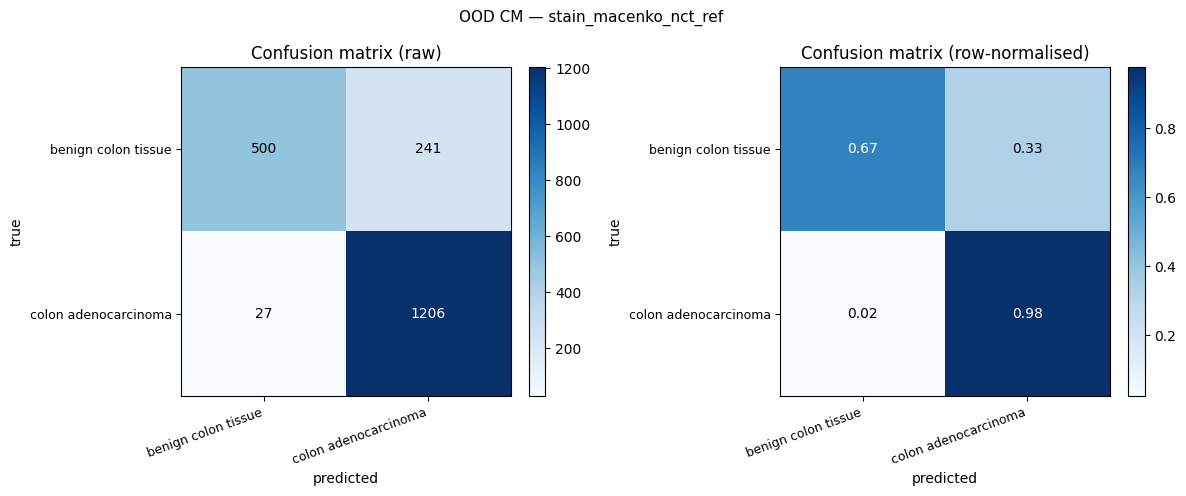

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/stain_macenko_nct_ref_ood_cm.png


In [11]:
# --- Cell 10: plot CM ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title, fmt, cmap in [
    (axes[0], cm_raw,  "Confusion matrix (raw)",         "d",   "Blues"),
    (axes[1], cm_norm, "Confusion matrix (row-normalised)", ".2f", "Blues"),
]:
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(target_names, rotation=20, ha="right", fontsize=9)
    ax.set_yticklabels(target_names, fontsize=9)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                    color="white" if mat[i, j] > mat.max() * 0.6 else "black", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f"OOD CM — {VARIANT}", fontsize=11)
plt.tight_layout()
cm_path = PLOTS_DIR / f"{VARIANT}_ood_cm.png"
fig.savefig(cm_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {cm_path}")


## 11 — Cross-dataset UMAP setup

To put NCT-CRC and LC25000 colon tiles in the same coordinate system, we encode the LC25000 colon test subset with the same baseline model and fit a single UMAP over

```
[ LC25000 colon images  ||  NCT NORM/TUM images  ||  2 colon class-prompt vectors ]
```

The four downstream plots all read from this one shared fit so positions are comparable across panels.

Loading: re-runs `discover_records` on the kagglehub-cached LC25000 dataset (~2 GB; cached locally on Colab after the baseline training), loads the same canonical split that the baseline saw, and filters to the two colon classes.


In [12]:
# --- Cell 11: load full LC25000 test set + encode + fit combined UMAP ---
import umap
import kagglehub
from src.data.lc25000 import discover_records, stratified_split, save_split, load_split

LC_SPLIT_PATH = results_dir("splits") / f"lc25000_seed{SEED}.json"
if LC_SPLIT_PATH.exists():
    lc_split = load_split(LC_SPLIT_PATH)
    print(f"Loaded existing split from {LC_SPLIT_PATH}")
else:
    print("Downloading LC25000 via kagglehub (cached after first run)...")
    lc_dataset_path = kagglehub.dataset_download(
        "andrewmvd/lung-and-colon-cancer-histopathological-images"
    )
    all_paths, all_indices = discover_records(lc_dataset_path)  # dedupe applied by default
    lc_split = stratified_split(all_paths, all_indices,
                                val_fraction=0.10, test_fraction=0.10, seed=SEED)
    save_split(lc_split, LC_SPLIT_PATH)
    print(f"Built + saved split at {LC_SPLIT_PATH}")

lc_test_paths   = np.asarray(lc_split["test_paths"])
lc_test_indices = np.asarray(lc_split["test_indices"], dtype=np.int32)
print(f"\nLC25000 full test set: {len(lc_test_paths)} images")
for idx in range(len(CLASS_INFO)):
    n = int((lc_test_indices == idx).sum())
    print(f"  class {idx} ({INDEX_TO_NAME[idx]}): {n}")

# Convenience masks / subsets.
lc_colon_mask  = np.isin(lc_test_indices, COLON_IDX)
lc_colon_paths    = lc_test_paths[lc_colon_mask]
lc_colon_indices  = lc_test_indices[lc_colon_mask]

print(f"\nEncoding all {len(lc_test_paths)} LC25000 test images...")
lc_test_embeddings = encode_paths(lc_test_paths)
print(f"LC25000 test embeddings shape: {lc_test_embeddings.shape}")
lc_colon_embeddings = lc_test_embeddings[lc_colon_mask]

# Fit one UMAP over [LC_all_5_classes, NCT, 5_prompts] so all plots share coordinates.
print(f"\nFitting combined UMAP over {len(lc_test_embeddings) + len(ood_embeddings) + len(prompt_embeddings_all)} points...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
combined = np.vstack([lc_test_embeddings, ood_embeddings, prompt_embeddings_all])
combined_2d = reducer.fit_transform(combined)

n_lc, n_nct, n_prompts = len(lc_test_embeddings), len(ood_embeddings), len(prompt_embeddings_all)
lc_2d        = combined_2d[:n_lc]
nct_2d       = combined_2d[n_lc:n_lc + n_nct]
prompt_2d    = combined_2d[n_lc + n_nct:]                # 5 prompt positions, indexed by class id
lc_colon_2d  = lc_2d[lc_colon_mask]                       # convenience view for colon subset
prompt_2d_colon = prompt_2d[COLON_IDX]                    # convenience view for the 2 colon prompts
print(f"  lc_2d={lc_2d.shape}  nct_2d={nct_2d.shape}  prompt_2d={prompt_2d.shape}")


Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Built + saved split at /content/histopathology-clip-lab/data/splits/lc25000_seed42.json

LC25000 full test set: 2372 images
  class 0 (benign lung tissue): 475
  class 1 (lung adenocarcinoma): 472
  class 2 (lung squamous cell carcinoma): 473
  class 3 (benign colon tissue): 477
  class 4 (colon adenocarcinoma): 475

Encoding all 2372 LC25000 test images...
LC25000 test embeddings shape: (2372, 256)

Fitting combined UMAP over 4351 points...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  lc_2d=(2372, 2)  nct_2d=(1974, 2)  prompt_2d=(5, 2)


## 12 — Scatter plots: NCT only and LC25000 + NCT combined

Two scatter views from the shared UMAP fit:

- **Plot 1** — only the NCT NORM/TUM points (with the 2 colon prompt stars). Same as the previous plot but the prompt stars are now *coloured* (blue for benign colon, red for adenocarcinoma) instead of two indistinguishable black stars.
- **Plot 2** — adds the LC25000 colon test set on top. LC25000 samples are drawn as circles, NCT samples as triangles. Class colour is shared. This is the visual answer to "do LC25000 colon and NCT colon land in the same place in embedding space, or are they pulled apart by the dataset shift?"


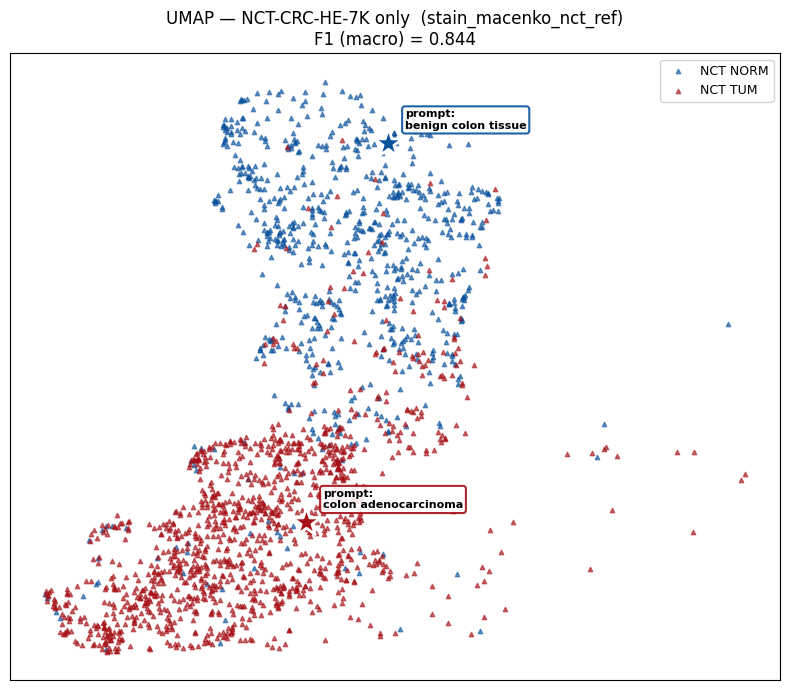

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/stain_macenko_nct_ref_ood_umap_nct_only.png


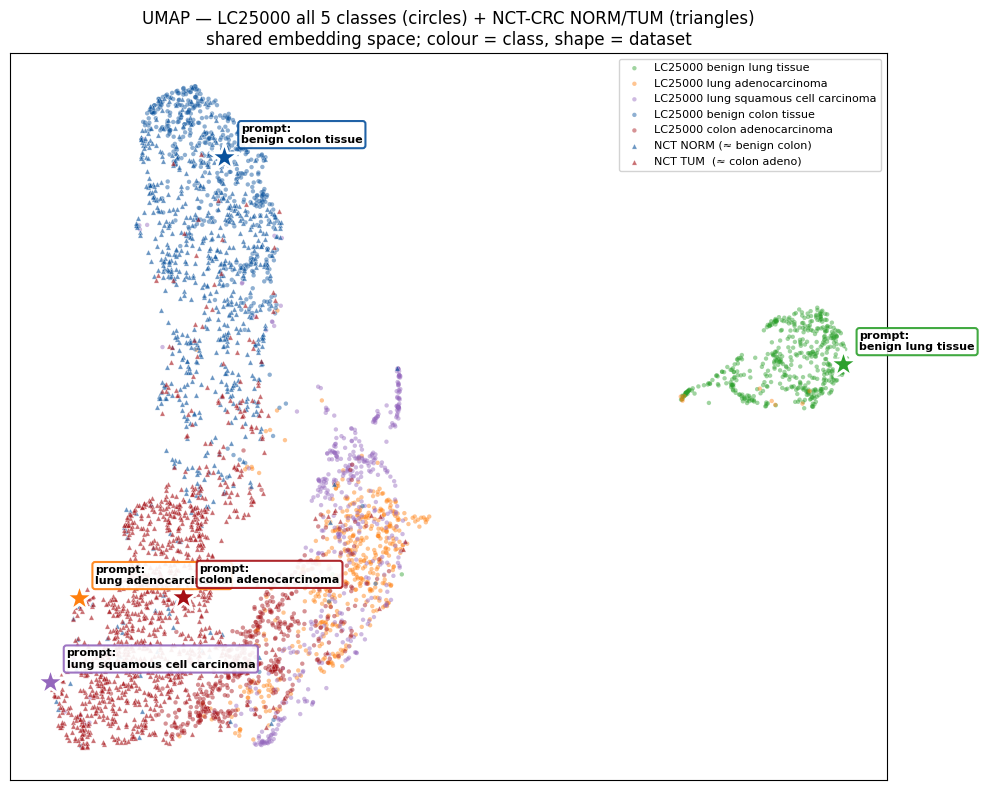

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/stain_macenko_nct_ref_ood_umap_combined.png


In [13]:
# --- Cell 12: scatter plots ---
# Per-class colour palette spanning all 5 LC25000 classes.
CLASS_COLOR = {
    0: "#2ca02c",  # benign lung tissue           — green
    1: "#ff7f0e",  # lung adenocarcinoma          — orange
    2: "#9467bd",  # lung squamous cell carcinoma — purple
    3: "#08519c",  # benign colon tissue          — blue
    4: "#a50f15",  # colon adenocarcinoma         — red
}
BENIGN_COLOR = CLASS_COLOR[3]   # backwards-compat for NCT helpers below
ADENO_COLOR  = CLASS_COLOR[4]


def draw_prompt_stars(ax, prompt_2d_, prompt_indices, *, with_labels=True, size=460):
    """Coloured stars + class-name annotation for the listed prompts."""
    for k, idx in enumerate(prompt_indices):
        color = CLASS_COLOR[idx]
        ax.scatter(prompt_2d_[k, 0], prompt_2d_[k, 1], s=size, marker="*",
                   c=color, edgecolors="white", linewidths=2.0, zorder=6)
        if with_labels:
            ax.annotate(
                f"prompt:\n{INDEX_TO_NAME[idx]}",
                (prompt_2d_[k, 0], prompt_2d_[k, 1]),
                xytext=(12, 10), textcoords="offset points",
                fontsize=8, fontweight="bold", zorder=7,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                          edgecolor=color, alpha=0.9, linewidth=1.5),
            )


# Plot 1 — NCT only with the 2 colon prompts (NCT has no lung tissue, so only
# the two colon prompts are relevant for classification on this set).
fig1, ax1 = plt.subplots(figsize=(8, 7))
for nct_cls, color in (("NORM", BENIGN_COLOR), ("TUM", ADENO_COLOR)):
    mask = (ood_nct_labels == nct_cls)
    ax1.scatter(nct_2d[mask, 0], nct_2d[mask, 1], s=10, alpha=0.6,
                c=color, marker="^", label=f"NCT {nct_cls}")
draw_prompt_stars(ax1, prompt_2d_colon, COLON_IDX)
ax1.legend(loc="best", fontsize=9, framealpha=0.85)
ax1.set_xticks([]); ax1.set_yticks([])
ax1.set_title(f"UMAP — NCT-CRC-HE-7K only  ({VARIANT})\nF1 (macro) = {macro_f1:.3f}")
plt.tight_layout()
p1 = PLOTS_DIR / f"{VARIANT}_ood_umap_nct_only.png"
fig1.savefig(p1, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p1}")

# Plot 2 — combined: all 5 LC25000 classes (circles) + 2 NCT classes (triangles) + 5 prompt stars.
fig2, ax2 = plt.subplots(figsize=(10, 8))
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax2.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=10, alpha=0.45,
                c=CLASS_COLOR[idx], marker="o",
                label=f"LC25000 {INDEX_TO_NAME[idx]}", edgecolors="none")
ax2.scatter(nct_2d[ood_nct_labels == "NORM", 0], nct_2d[ood_nct_labels == "NORM", 1],
            s=14, alpha=0.6, c=BENIGN_COLOR, marker="^",
            label="NCT NORM (≈ benign colon)", edgecolors="white", linewidths=0.3)
ax2.scatter(nct_2d[ood_nct_labels == "TUM", 0], nct_2d[ood_nct_labels == "TUM", 1],
            s=14, alpha=0.6, c=ADENO_COLOR, marker="^",
            label="NCT TUM  (≈ colon adeno)", edgecolors="white", linewidths=0.3)
draw_prompt_stars(ax2, prompt_2d, list(range(len(CLASS_INFO))))
ax2.legend(loc="best", fontsize=8, framealpha=0.85)
ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_title("UMAP — LC25000 all 5 classes (circles) + NCT-CRC NORM/TUM (triangles)\n"
              "shared embedding space; colour = class, shape = dataset")
plt.tight_layout()
p2 = PLOTS_DIR / f"{VARIANT}_ood_umap_combined.png"
fig2.savefig(p2, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p2}")


## 13 — Thumbnail plots: actual tissue images at their UMAP positions

Same coordinate system as Plots 1–2, but each thumbnail is the real patch (resized to 56×56). The border colour encodes the class (blue = benign colon, red = colon adeno), and — only on the combined plot — a thicker double border encodes the dataset (no inner border = LC25000, white inner border = NCT). This makes class-mismatch cases (a thumbnail of class A sitting in class B's cluster) and dataset-shift cases (NCT clusters drifting away from LC25000 clusters of the same class) visually obvious.

The thumbnail layout uses the project's standard "no two thumbnails within `min_dist`" rule so the plot is readable.


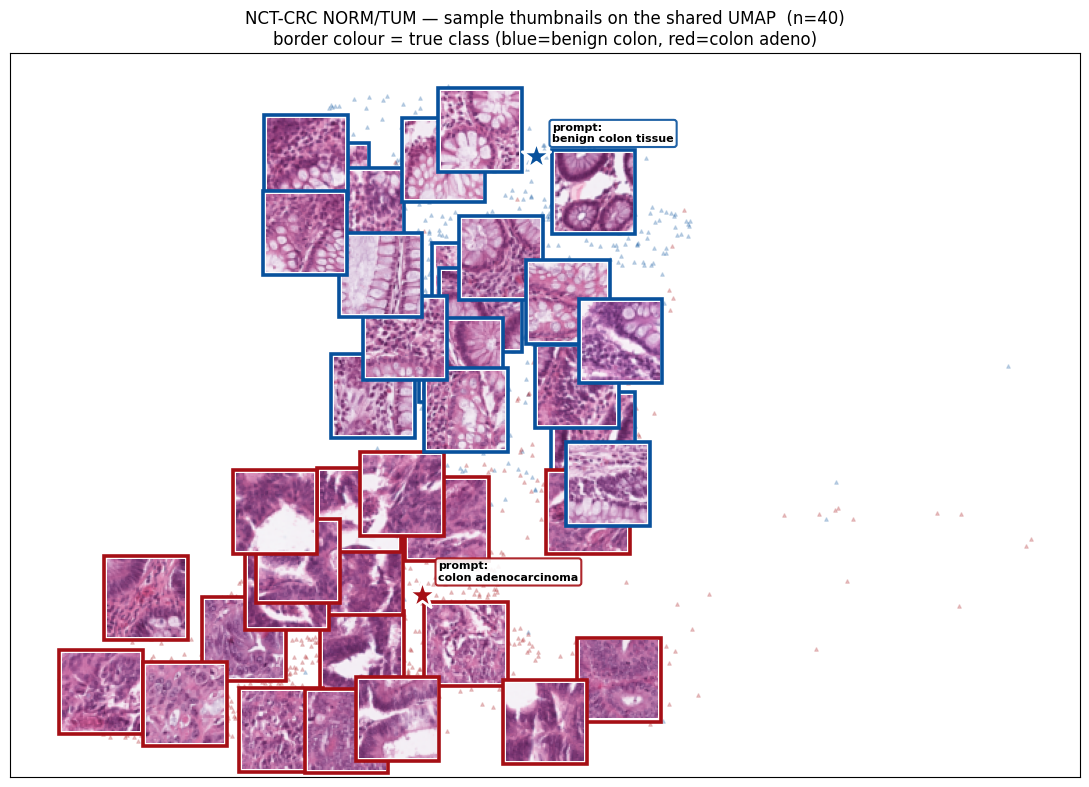

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/stain_macenko_nct_ref_ood_umap_nct_thumbnails.png


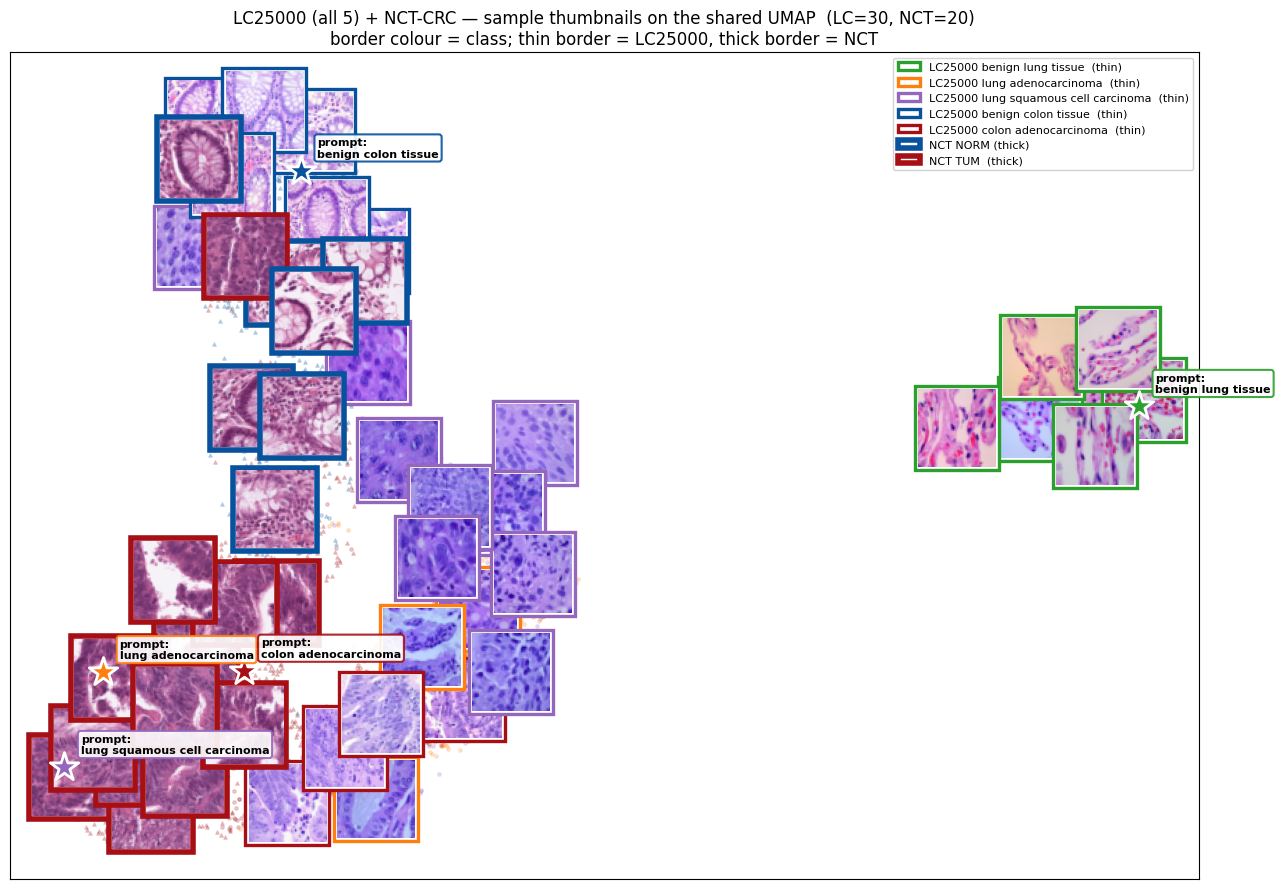

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/stain_macenko_nct_ref_ood_umap_combined_thumbnails.png


In [14]:
# --- Cell 13: thumbnail plots ---
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import Patch


def _read_thumb(path, size=(56, 56)):
    try:
        im = Image.open(path).convert("RGB").resize(size, Image.BILINEAR)
        return np.asarray(im)
    except Exception:
        return np.full((size[1], size[0], 3), 200, dtype=np.uint8)


def _layout_thumbnails(ax, coords, paths, class_colors, *, max_thumbs=40,
                       thumb_size=(56, 56), min_dist_frac=0.045, seed=42,
                       border_width=2.6):
    """Place up to max_thumbs thumbnails greedily so none are within min_dist of each other.

    class_colors: list aligned with coords/paths — the border colour for each thumbnail.
    """
    coords = np.asarray(coords)
    rng = np.random.default_rng(seed)
    x_range = float(coords[:, 0].max() - coords[:, 0].min())
    y_range = float(coords[:, 1].max() - coords[:, 1].min())
    min_dist = min_dist_frac * min(x_range, y_range)
    idx = np.arange(len(coords)); rng.shuffle(idx)
    placed = []
    for i in idx:
        x, y = float(coords[i, 0]), float(coords[i, 1])
        if any((x - px) ** 2 + (y - py) ** 2 < min_dist ** 2 for (px, py) in placed):
            continue
        thumb = _read_thumb(paths[i], size=thumb_size)
        ab = AnnotationBbox(
            OffsetImage(thumb, zoom=1.0), (x, y),
            frameon=True, pad=0.22,
            bboxprops=dict(linewidth=border_width, edgecolor=class_colors[i]),
        )
        ax.add_artist(ab)
        placed.append((x, y))
        if len(placed) >= max_thumbs:
            break
    return len(placed)


# Plot 3 — NCT-only thumbnails.
fig3, ax3 = plt.subplots(figsize=(11, 8))
for nct_cls, color in (("NORM", BENIGN_COLOR), ("TUM", ADENO_COLOR)):
    mask = (ood_nct_labels == nct_cls)
    ax3.scatter(nct_2d[mask, 0], nct_2d[mask, 1], s=6, alpha=0.20, c=color, marker="^")
nct_thumb_colors = [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))]
n_thumbs_3 = _layout_thumbnails(
    ax3, nct_2d, list(ood_paths), nct_thumb_colors,
    max_thumbs=40, min_dist_frac=0.06, seed=SEED,
)
draw_prompt_stars(ax3, prompt_2d_colon, COLON_IDX, with_labels=True)
ax3.set_xticks([]); ax3.set_yticks([])
ax3.set_title(f"NCT-CRC NORM/TUM — sample thumbnails on the shared UMAP  (n={n_thumbs_3})\n"
              "border colour = true class (blue=benign colon, red=colon adeno)")
plt.tight_layout()
p3 = PLOTS_DIR / f"{VARIANT}_ood_umap_nct_thumbnails.png"
fig3.savefig(p3, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p3}")


# Plot 4 — combined LC25000 (all 5 classes) + NCT thumbnails.
# Border colour encodes class; border WIDTH encodes dataset (thin = LC25000, thick = NCT).
fig4, ax4 = plt.subplots(figsize=(13, 9))
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax4.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=6, alpha=0.18, c=CLASS_COLOR[idx], marker="o")
ax4.scatter(nct_2d[ood_nct_labels == "NORM", 0], nct_2d[ood_nct_labels == "NORM", 1],
            s=6, alpha=0.20, c=BENIGN_COLOR, marker="^")
ax4.scatter(nct_2d[ood_nct_labels == "TUM", 0], nct_2d[ood_nct_labels == "TUM", 1],
            s=6, alpha=0.20, c=ADENO_COLOR, marker="^")

lc_thumb_colors  = [CLASS_COLOR[int(lc_test_indices[i])] for i in range(len(lc_test_paths))]
nct_thumb_colors = [CLASS_COLOR[int(ood_lc_indices[i])]   for i in range(len(ood_paths))]
n_lc_thumbs  = _layout_thumbnails(
    ax4, lc_2d, list(lc_test_paths), lc_thumb_colors,
    max_thumbs=30, min_dist_frac=0.06, seed=SEED, border_width=2.4,
)
n_nct_thumbs = _layout_thumbnails(
    ax4, nct_2d, list(ood_paths), nct_thumb_colors,
    max_thumbs=20, min_dist_frac=0.06, seed=SEED + 1, border_width=4.0,
)
draw_prompt_stars(ax4, prompt_2d, list(range(len(CLASS_INFO))), with_labels=True)

legend_elements = [
    Patch(facecolor="white", edgecolor=CLASS_COLOR[i], linewidth=2.4,
          label=f"LC25000 {INDEX_TO_NAME[i]}  (thin)")
    for i in range(len(CLASS_INFO))
] + [
    Patch(facecolor="white", edgecolor=BENIGN_COLOR, linewidth=4.0, label="NCT NORM (thick)"),
    Patch(facecolor="white", edgecolor=ADENO_COLOR,  linewidth=4.0, label="NCT TUM  (thick)"),
]
ax4.legend(handles=legend_elements, loc="best", fontsize=8, framealpha=0.85)
ax4.set_xticks([]); ax4.set_yticks([])
ax4.set_title(f"LC25000 (all 5) + NCT-CRC — sample thumbnails on the shared UMAP  "
              f"(LC={n_lc_thumbs}, NCT={n_nct_thumbs})\n"
              "border colour = class; thin border = LC25000, thick border = NCT")
plt.tight_layout()
p4 = PLOTS_DIR / f"{VARIANT}_ood_umap_combined_thumbnails.png"
fig4.savefig(p4, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p4}")


## 14 — Three-dataset comparison panel

All three views side-by-side in one 2×3 figure:

| Row \ Col | LC25000 all 5 | LC25000 colon only | NCT NORM/TUM |
|---|---|---|---|
| **Scatter** | colour by class, 5 prompt stars | colour by class, 2 colon prompts | NCT triangles, 2 colon prompts |
| **Thumbnails** | sample images with class-coloured borders | same, colon only | same, NCT only |

Every panel shares the same UMAP coordinate system from Cell 11, so a given image lands at the same `(x, y)` regardless of which panel it appears in. The point of the panel is to show the three "views" of the same embedding space — useful for the defense to explain *what the model sees*.


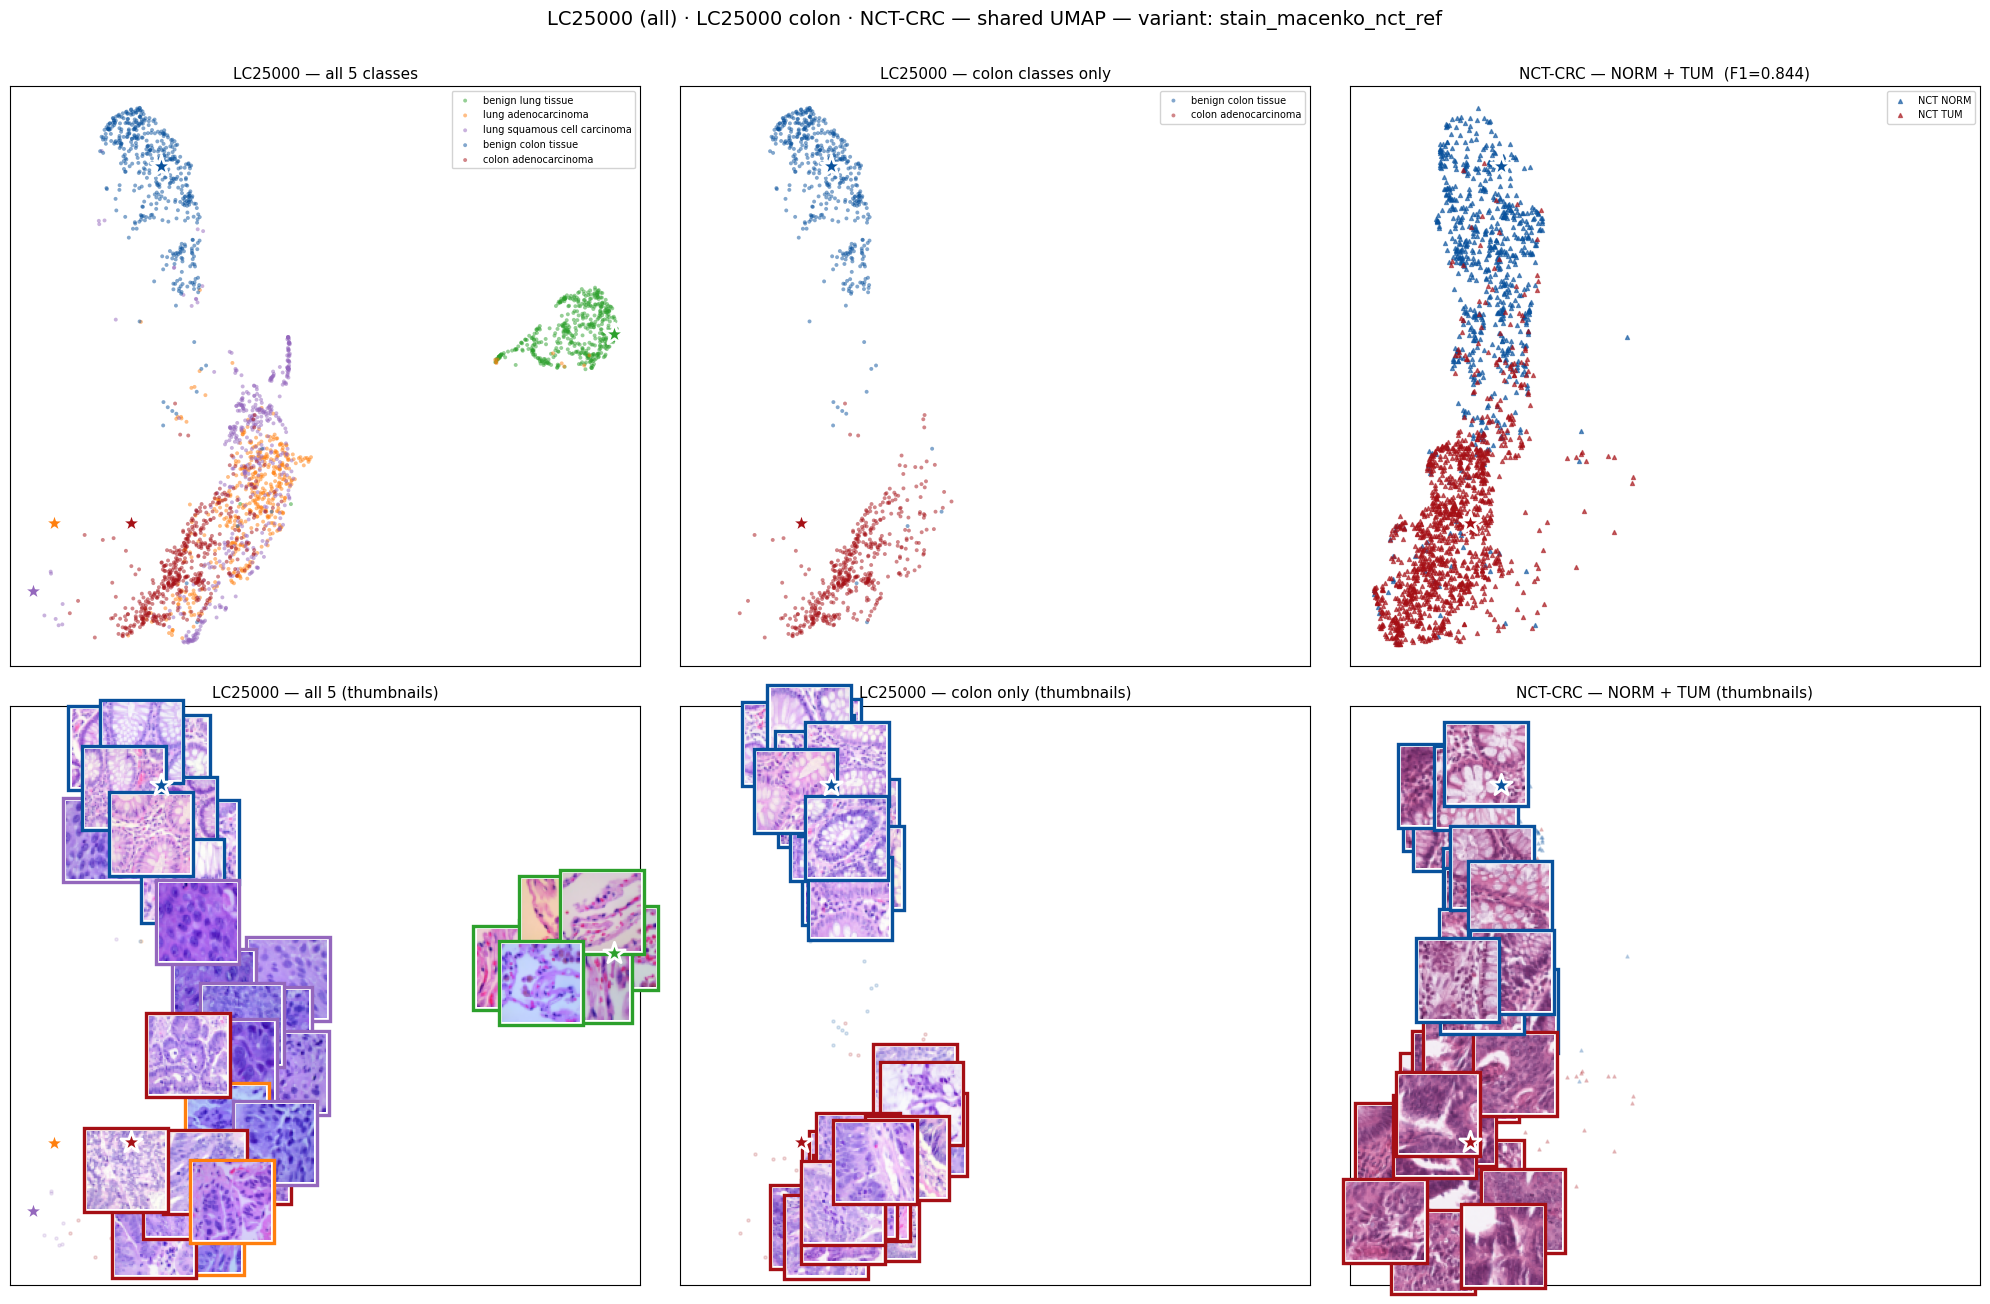

Saved /content/histopathology-clip-lab/results/plots/exp_07_ood_eval/stain_macenko_nct_ref_ood_umap_grid.png


In [15]:
# --- Cell 14: 2x3 comparison panel ---
fig, axes = plt.subplots(2, 3, figsize=(20, 13))

# Compute shared axis limits so all 6 panels show the same UMAP region.
x_min = min(lc_2d[:, 0].min(), nct_2d[:, 0].min(), prompt_2d[:, 0].min())
x_max = max(lc_2d[:, 0].max(), nct_2d[:, 0].max(), prompt_2d[:, 0].max())
y_min = min(lc_2d[:, 1].min(), nct_2d[:, 1].min(), prompt_2d[:, 1].min())
y_max = max(lc_2d[:, 1].max(), nct_2d[:, 1].max(), prompt_2d[:, 1].max())
pad_x = 0.04 * (x_max - x_min)
pad_y = 0.04 * (y_max - y_min)
XLIM = (x_min - pad_x, x_max + pad_x)
YLIM = (y_min - pad_y, y_max + pad_y)


def _set_box(ax, title):
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=11)


# --- ROW 1 — SCATTER ---
# (0, 0) LC25000 all 5 classes.
ax = axes[0, 0]
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=8, alpha=0.5,
               c=CLASS_COLOR[idx], marker="o", label=INDEX_TO_NAME[idx], edgecolors="none")
draw_prompt_stars(ax, prompt_2d, list(range(len(CLASS_INFO))), with_labels=False, size=260)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_set_box(ax, "LC25000 — all 5 classes")

# (0, 1) LC25000 colon only.
ax = axes[0, 1]
for idx in COLON_IDX:
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=8, alpha=0.5,
               c=CLASS_COLOR[idx], marker="o", label=INDEX_TO_NAME[idx], edgecolors="none")
draw_prompt_stars(ax, prompt_2d_colon, COLON_IDX, with_labels=False, size=260)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_set_box(ax, "LC25000 — colon classes only")

# (0, 2) NCT only.
ax = axes[0, 2]
for nct_cls, color in (("NORM", BENIGN_COLOR), ("TUM", ADENO_COLOR)):
    mask = (ood_nct_labels == nct_cls)
    ax.scatter(nct_2d[mask, 0], nct_2d[mask, 1], s=8, alpha=0.6,
               c=color, marker="^", label=f"NCT {nct_cls}")
draw_prompt_stars(ax, prompt_2d_colon, COLON_IDX, with_labels=False, size=260)
ax.legend(loc="best", fontsize=7, framealpha=0.85)
_set_box(ax, f"NCT-CRC — NORM + TUM  (F1={macro_f1:.3f})")


# --- ROW 2 — THUMBNAILS ---
# Faint scatter under each thumbnail panel (so cluster shape is still readable).
# (1, 0) LC25000 all 5 thumbnails.
ax = axes[1, 0]
for idx in range(len(CLASS_INFO)):
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=5, alpha=0.15, c=CLASS_COLOR[idx], marker="o")
_layout_thumbnails(
    ax, lc_2d, list(lc_test_paths),
    [CLASS_COLOR[int(lc_test_indices[i])] for i in range(len(lc_test_paths))],
    max_thumbs=35, min_dist_frac=0.06, seed=SEED, border_width=2.4,
)
draw_prompt_stars(ax, prompt_2d, list(range(len(CLASS_INFO))), with_labels=False, size=260)
_set_box(ax, "LC25000 — all 5 (thumbnails)")

# (1, 1) LC25000 colon only thumbnails.
ax = axes[1, 1]
for idx in COLON_IDX:
    mask = (lc_test_indices == idx)
    ax.scatter(lc_2d[mask, 0], lc_2d[mask, 1], s=5, alpha=0.15, c=CLASS_COLOR[idx], marker="o")
_layout_thumbnails(
    ax, lc_colon_2d, list(lc_colon_paths),
    [CLASS_COLOR[int(lc_colon_indices[i])] for i in range(len(lc_colon_paths))],
    max_thumbs=30, min_dist_frac=0.06, seed=SEED, border_width=2.4,
)
draw_prompt_stars(ax, prompt_2d_colon, COLON_IDX, with_labels=False, size=260)
_set_box(ax, "LC25000 — colon only (thumbnails)")

# (1, 2) NCT only thumbnails.
ax = axes[1, 2]
for nct_cls, color in (("NORM", BENIGN_COLOR), ("TUM", ADENO_COLOR)):
    mask = (ood_nct_labels == nct_cls)
    ax.scatter(nct_2d[mask, 0], nct_2d[mask, 1], s=5, alpha=0.20, c=color, marker="^")
_layout_thumbnails(
    ax, nct_2d, list(ood_paths),
    [CLASS_COLOR[int(ood_lc_indices[i])] for i in range(len(ood_paths))],
    max_thumbs=30, min_dist_frac=0.06, seed=SEED, border_width=2.4,
)
draw_prompt_stars(ax, prompt_2d_colon, COLON_IDX, with_labels=False, size=260)
_set_box(ax, "NCT-CRC — NORM + TUM (thumbnails)")


fig.suptitle(f"LC25000 (all) · LC25000 colon · NCT-CRC — shared UMAP — variant: {VARIANT}",
             fontsize=14, y=1.005)
plt.tight_layout()
p_grid = PLOTS_DIR / f"{VARIANT}_ood_umap_grid.png"
fig.savefig(p_grid, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved {p_grid}")


## Summary

Run-time output (filenames include the active `VARIANT`):
- `results/metrics/exp_07_ood_eval/{VARIANT}_ood_classification.json`
- `results/confusion_matrices/exp_07_ood_eval/{VARIANT}_ood_cm_{raw,norm}.npy`
- `results/plots/exp_07_ood_eval/{VARIANT}_ood_cm.png`
- `results/plots/exp_07_ood_eval/{VARIANT}_ood_umap_nct_only.png`
- `results/plots/exp_07_ood_eval/{VARIANT}_ood_umap_combined.png`
- `results/plots/exp_07_ood_eval/{VARIANT}_ood_umap_nct_thumbnails.png`
- `results/plots/exp_07_ood_eval/{VARIANT}_ood_umap_combined_thumbnails.png`
- `results/plots/exp_07_ood_eval/{VARIANT}_ood_umap_grid.png`

**To run a different variant**, change `VARIANT` in Cell 2 and re-execute from Cell 6 onwards (Cells 0–5 are setup that doesn't depend on the checkpoint). Each variant writes its own files so reruns are non-destructive.

**Next iterations** (not in this notebook):
1. Fix `exp_02_plip_zeroshot` 0.0000 bug and add PLIP-on-NCT to the comparison
2. Train on NCT-CRC-HE-100K, evaluate on LC25000 colon subset — the reverse-direction OOD
